# 07 Decision Tree Fraud Detection Model

## Model Plan

In [37]:
from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000


## Load Cleaned Data


In [38]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape


(8914963, 8)

In [39]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")


is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering


In [40]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)
model_data["merchant_state"] = model_data["merchant_state"].fillna("Unknown")
model_data["use_chip"] = model_data["use_chip"].fillna("Unknown")
model_data["mcc"] = model_data["mcc"].astype(str)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

model_data = model_data.dropna(subset=feature_columns + ["is_fraud"])
X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})


,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

In [41]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    sampled = model_data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    # Re-sample with stratification to preserve the rare fraud class ratio.
    sampled, _ = train_test_split(
        model_data,
        train_size=SAMPLE_SIZE,
        stratify=model_data["is_fraud"],
        random_state=RANDOM_STATE,
    )
    X = sampled[feature_columns]
    y = sampled["is_fraud"].astype(int)

pd.DataFrame(
    {
        "rows_used": [len(X)],
        "fraud_count": [int(y.sum())],
        "fraud_rate_percent": [round(y.mean() * 100, 4)],
    }
)


,rows_used,fraud_count,fraud_rate_percent
0,500000,748,0.1496


## Train-Test Split


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud_rate_percent": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)


,dataset,rows,fraud_rate_percent
0,train,375000,0.1496
1,test,125000,0.1496


## Build Decision Tree Pipeline


In [43]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", decision_tree_model),
    ]
)
print("Decision Tree pipeline created.")


Decision Tree pipeline created.


## Train Model


In [44]:
start_time = time.perf_counter()
decision_tree_pipeline.fit(X_train, y_train)
print("Decision Tree model trained.")
training_time_seconds = time.perf_counter() - start_time
round(training_time_seconds, 2)


Decision Tree model trained.


7.17

## Complexity and Efficiency Notes

In [45]:
encoded_feature_count = len(decision_tree_pipeline.named_steps["preprocess"].get_feature_names_out())
complexity_summary = pd.DataFrame(
    {
        "item": [
            "training rows",
            "test rows",
            "input features before encoding",
            "features after one-hot encoding",
            "maximum tree depth",
            "minimum samples per leaf",
            "training time seconds",
        ],
        "value": [
            len(X_train),
            len(X_test),
            len(feature_columns),
            encoded_feature_count,
            decision_tree_pipeline.named_steps["model"].max_depth,
            decision_tree_pipeline.named_steps["model"].min_samples_leaf,
            round(training_time_seconds, 2),
        ],
    }
)
complexity_summary


,item,value
0,training rows,375000.00
1,test rows,125000.00
2,input features before encoding,9.00
3,features after one-hot encoding,262.00
4,maximum tree depth,12.00
5,minimum samples per leaf,25.00
6,training time seconds,7.17


## Evaluate Model


In [46]:
y_pred = decision_tree_pipeline.predict(X_test)
y_score = decision_tree_pipeline.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame(
    {
        "model": ["Decision Tree"],
        "accuracy": [accuracy_score(y_test, y_pred)],
        "roc_auc": [roc_auc_score(y_test, y_score)],
        "pr_auc": [average_precision_score(y_test, y_score)],
        "training_time_seconds": [training_time_seconds],
    }
)
metrics_summary.round(4)


,model,accuracy,roc_auc,pr_auc,training_time_seconds
0,Decision Tree,0.9682,0.8882,0.1947,7.1692


In [47]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud"], digits=4))


              precision    recall  f1-score   support

   Non-fraud     0.9998    0.9684    0.9838    124813
       Fraud     0.0383    0.8396    0.0732       187

    accuracy                         0.9682    125000
   macro avg     0.5190    0.9040    0.5285    125000
weighted avg     0.9983    0.9682    0.9825    125000



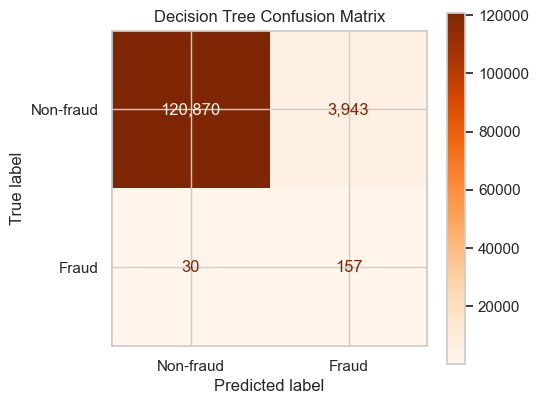

In [48]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Oranges",
    values_format=",d",
    ax=ax,
)
ax.set_title("Decision Tree Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_decision_tree_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


## Threshold Review


In [49]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    threshold_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(4)


,threshold,precision,recall,f1,false_positives,false_negatives
0,0.1,0.0255,0.8449,0.0496,6027,29
1,0.2,0.0255,0.8449,0.0496,6027,29
2,0.3,0.0255,0.8449,0.0496,6027,29
3,0.4,0.0363,0.8396,0.0697,4164,30
4,0.5,0.0383,0.8396,0.0732,3943,30


## Decision Tree Threshold Trade-Off Graph


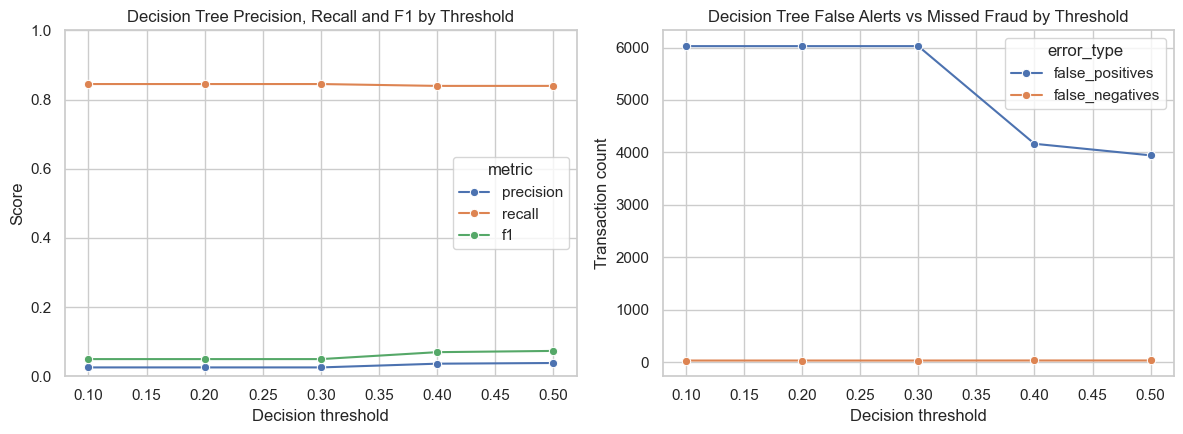

In [50]:
threshold_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", marker="o", ax=axes[0])
axes[0].set_title("Decision Tree Precision, Recall and F1 by Threshold")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)

error_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["false_positives", "false_negatives"],
    var_name="error_type",
    value_name="count",
)
sns.lineplot(data=error_plot, x="threshold", y="count", hue="error_type", marker="o", ax=axes[1])
axes[1].set_title("Decision Tree False Alerts vs Missed Fraud by Threshold")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Transaction count")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_decision_tree_threshold_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()


## Precision-Recall Curve


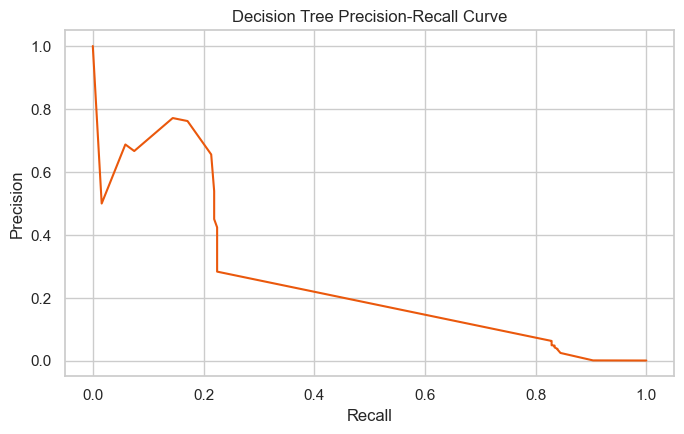

In [51]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#ea580c")
ax.set_title("Decision Tree Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_decision_tree_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()


## ROC Curve


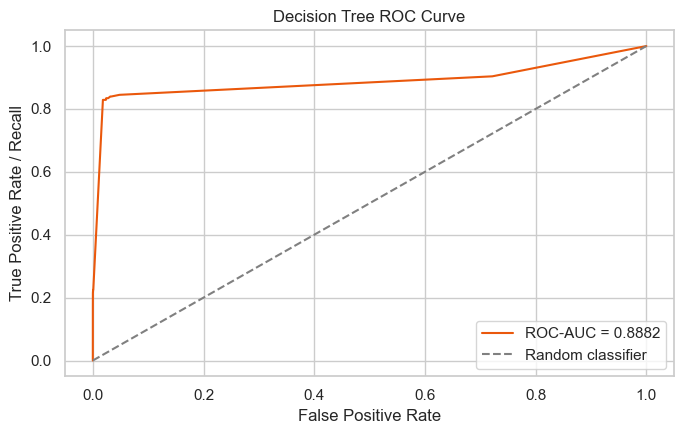

In [52]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(false_positive_rate, true_positive_rate, color="#ea580c", label=f"ROC-AUC = {roc_auc_score(y_test, y_score):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("Decision Tree ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_decision_tree_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()


## Feature Importance


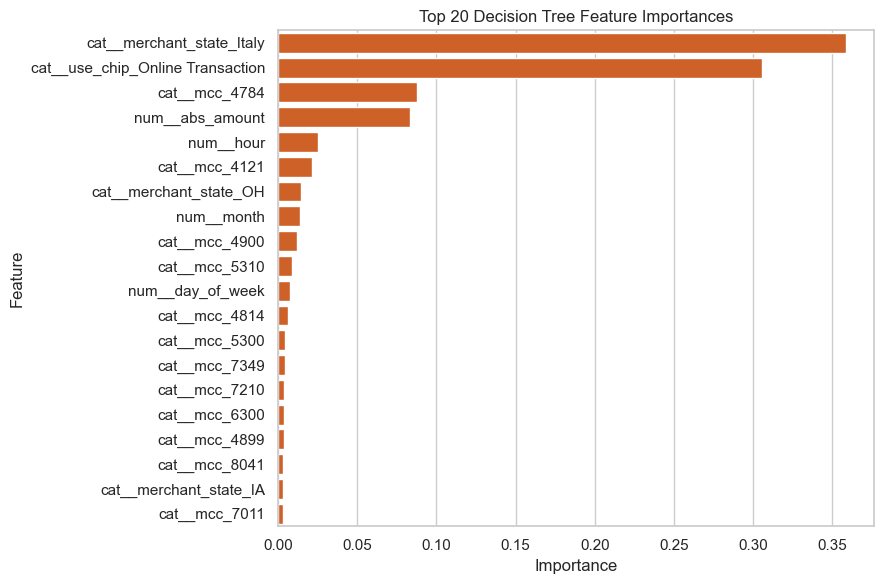

,feature,importance
67,cat__merchant_state_Italy,0.358455
7,cat__use_chip_Online Transaction,0.305325
194,cat__mcc_4784,0.087855
0,num__abs_amount,0.083315
2,num__hour,0.024916
188,cat__mcc_4121,0.021553
104,cat__merchant_state_OH,0.014213
4,num__month,0.013739
198,cat__mcc_4900,0.011895
207,cat__mcc_5310,0.008892


In [53]:
feature_names = decision_tree_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = decision_tree_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_importance, y="feature", x="importance", color="#ea580c", ax=ax)
ax.set_title("Top 20 Decision Tree Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_decision_tree_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

feature_importance


## Save Model


In [54]:
model_path = MODEL_DIR / "decision_tree_fraud_model.joblib"
joblib.dump(decision_tree_pipeline, model_path)
model_path


PosixPath('/Users/zichen/Big-Data-Project/models/decision_tree_fraud_model.joblib')